## Imports

In [27]:
from __future__ import annotations

import time

from copy import deepcopy
from pathlib import Path
from tempfile import TemporaryDirectory

import lightgbm as lgb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from mlflow.models import infer_signature

from walmart_forecasting.data import (
    load_merged_data,
)
from walmart_forecasting.experiment import (
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    make_run_name,
    save_architecture_result,
)
from walmart_forecasting.features import (
    add_basic_features,
    add_exact_lag_features,
)
from walmart_forecasting.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    weighted_mae,
)
from walmart_forecasting.preprocessing import (
    build_tree_preprocessor,
)
from walmart_forecasting.tracking import (
    mlflow_run,
)
from walmart_forecasting.validation import (
    competition_like_holdout,
    expanding_window_splits,
)


pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

## Configuration

In [2]:
ARCHITECTURE = "lightgbm"
EXPERIMENT_NAME = "LightGBM_Training"

HOLIDAY_WEIGHT = 5.0
NON_HOLIDAY_WEIGHT = 1.0

EARLY_STOPPING_ROUNDS = 100

BASE_PARAMETERS = {
    "n_estimators": 2500,
    "learning_rate": 0.03,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 40,
    "subsample": 0.90,
    "subsample_freq": 1,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.0,
    "reg_lambda": 0.10,
}

## Data loading and validation

In [3]:
data = load_merged_data()

train = data.train.copy()
test = data.test.copy()

final_split = competition_like_holdout(
    train_data=train,
    test_data=test,
)

cv_splits = expanding_window_splits(
    data=final_split.train,
    n_splits=CV_FOLDS,
    validation_weeks=CV_VALIDATION_WEEKS,
)

series_count = (
    final_split.train[
        ["Store", "Dept"]
    ]
    .drop_duplicates()
    .shape[0]
)

split_summary = pd.DataFrame(
    [
        {
            "split": f"cv_fold_{fold_number}",
            "train_start": (
                fold.train["Date"].min()
            ),
            "train_end": (
                fold.train["Date"].max()
            ),
            "validation_start": (
                fold.validation["Date"].min()
            ),
            "validation_end": (
                fold.validation["Date"].max()
            ),
            "train_rows": len(fold.train),
            "validation_rows": len(
                fold.validation
            ),
        }
        for fold_number, fold in enumerate(
            cv_splits,
            start=1,
        )
    ]
    + [
        {
            "split": "final_holdout",
            "train_start": (
                final_split.train[
                    "Date"
                ].min()
            ),
            "train_end": (
                final_split.train[
                    "Date"
                ].max()
            ),
            "validation_start": (
                final_split.validation[
                    "Date"
                ].min()
            ),
            "validation_end": (
                final_split.validation[
                    "Date"
                ].max()
            ),
            "train_rows": len(
                final_split.train
            ),
            "validation_rows": len(
                final_split.validation
            ),
        }
    ]
)

split_summary

,split,train_start,train_end,validation_start,validation_end,train_rows,validation_rows
0,cv_fold_1,2010-02-05,2011-04-29,2011-05-06,2011-07-29,190674,38164
1,cv_fold_2,2010-02-05,2011-07-29,2011-08-05,2011-10-28,228838,38346
2,cv_fold_3,2010-02-05,2011-10-28,2011-11-04,2012-01-27,267184,38798
3,final_holdout,2010-02-05,2012-01-27,2012-02-03,2012-10-26,305982,115588


## Feature preparation

In [4]:
def prepare_features(
    rows: pd.DataFrame,
    history: pd.DataFrame,
    lags: tuple[int, ...],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ordered_rows = (
        rows
        .sort_values(
            ["Date", "Store", "Dept"]
        )
        .reset_index(drop=True)
        .copy()
    )

    ordered_rows["_row_order"] = np.arange(
        len(ordered_rows)
    )

    features = add_basic_features(
        ordered_rows
    )

    if lags:
        features = add_exact_lag_features(
            rows=features,
            history=history,
            lags=lags,
        )

        for lag in lags:
            lag_column = f"lag_{lag}"

            features[
                f"{lag_column}_missing"
            ] = (
                features[lag_column]
                .isna()
                .astype("int8")
            )

    features = (
        features
        .sort_values("_row_order")
        .reset_index(drop=True)
    )

    ordered_rows = (
        ordered_rows
        .sort_values("_row_order")
        .drop(columns="_row_order")
        .reset_index(drop=True)
    )

    features = features.drop(
        columns=[
            "_row_order",
            "Weekly_Sales",
            "Date",
        ],
        errors="ignore",
    )

    return ordered_rows, features

In [5]:
def make_sample_weights(
    rows: pd.DataFrame,
) -> np.ndarray:
    return np.where(
        rows["IsHoliday"].astype(bool),
        HOLIDAY_WEIGHT,
        NON_HOLIDAY_WEIGHT,
    ).astype(float)


def evaluate_predictions(
    rows: pd.DataFrame,
    predictions: np.ndarray,
) -> dict[str, float]:
    return {
        "wmae": weighted_mae(
            y_true=rows[
                "Weekly_Sales"
            ],
            y_pred=predictions,
            is_holiday=rows[
                "IsHoliday"
            ],
        ),
        "mae": mean_absolute_error(
            y_true=rows[
                "Weekly_Sales"
            ],
            y_pred=predictions,
        ),
        "rmse": root_mean_squared_error(
            y_true=rows[
                "Weekly_Sales"
            ],
            y_pred=predictions,
        ),
    }

## Cross-validation trial runner

In [6]:
def run_cv_trial(
    trial: dict,
) -> tuple[dict, pd.DataFrame]:
    fold_results = []

    for fold_number, fold in enumerate(
        cv_splits,
        start=1,
    ):
        train_rows, train_features = (
            prepare_features(
                rows=fold.train,
                history=fold.train,
                lags=trial["lags"],
            )
        )

        validation_rows, validation_features = (
            prepare_features(
                rows=fold.validation,
                history=fold.train,
                lags=trial["lags"],
            )
        )

        extra_numeric_columns = []

        for lag in trial["lags"]:
            extra_numeric_columns.extend(
                [
                    f"lag_{lag}",
                    f"lag_{lag}_missing",
                ]
            )

        preprocessor = (
            build_tree_preprocessor(
                extra_numeric_columns=(
                    extra_numeric_columns
                ),
                include_economic=trial[
                    "include_economic"
                ],
                markdown_strategy=trial[
                    "markdown_strategy"
                ],
            )
        )

        x_train = (
            preprocessor.fit_transform(
                train_features
            )
        )

        x_validation = (
            preprocessor.transform(
                validation_features
            )
        )

        y_train = (
            train_rows["Weekly_Sales"]
            .to_numpy()
        )

        train_weights = (
            make_sample_weights(
                train_rows
            )
        )

        validation_weights = (
            make_sample_weights(
                validation_rows
            )
        )

        model = LGBMRegressor(
            objective="regression_l1",
            random_state=(
                DEFAULT_RANDOM_SEED
            ),
            n_jobs=-1,
            verbosity=-1,
            **trial["parameters"],
        )

        fit_start = time.perf_counter()

        model.fit(
            x_train,
            y_train,
            sample_weight=train_weights,
            eval_set=[
                (
                    x_validation,
                    validation_rows[
                        "Weekly_Sales"
                    ].to_numpy(),
                )
            ],
            eval_sample_weight=[
                validation_weights
            ],
            eval_metric="l1",
            callbacks=[
                lgb.early_stopping(
                    EARLY_STOPPING_ROUNDS,
                    verbose=False,
                ),
                lgb.log_evaluation(0),
            ],
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        best_iteration = int(
            model.best_iteration_
            or trial["parameters"][
                "n_estimators"
            ]
        )

        predict_start = (
            time.perf_counter()
        )

        predictions = model.predict(
            x_validation,
            num_iteration=best_iteration,
        )

        predict_seconds = (
            time.perf_counter()
            - predict_start
        )

        metrics = evaluate_predictions(
            rows=validation_rows,
            predictions=predictions,
        )

        if trial["lags"]:
            lag_coverage = float(
                validation_features[
                    [
                        f"lag_{lag}"
                        for lag in trial[
                            "lags"
                        ]
                    ]
                ]
                .notna()
                .all(axis=1)
                .mean()
            )
        else:
            lag_coverage = np.nan

        fold_results.append(
            {
                "fold": fold_number,
                "wmae": metrics["wmae"],
                "mae": metrics["mae"],
                "rmse": metrics["rmse"],
                "best_iteration": (
                    best_iteration
                ),
                "lag_coverage": (
                    lag_coverage
                ),
                "fit_seconds": (
                    fit_seconds
                ),
                "predict_seconds": (
                    predict_seconds
                ),
            }
        )

        print(
            f"{trial['trial_id']} | "
            f"fold={fold_number} | "
            f"WMAE={metrics['wmae']:,.2f} | "
            f"best_iteration="
            f"{best_iteration}"
        )

    fold_frame = pd.DataFrame(
        fold_results
    )

    summary = {
        "trial_id": trial["trial_id"],
        "trial_name": (
            trial["trial_name"]
        ),
        "feature_set": (
            trial["feature_set"]
        ),
        "preprocessing": (
            trial["preprocessing"]
        ),
        "lags": str(trial["lags"]),
        "include_economic": trial[
            "include_economic"
        ],
        "markdown_strategy": trial[
            "markdown_strategy"
        ],
        "cv_wmae_mean": float(
            fold_frame["wmae"].mean()
        ),
        "cv_wmae_std": float(
            fold_frame["wmae"]
            .std(ddof=0)
        ),
        "cv_mae_mean": float(
            fold_frame["mae"].mean()
        ),
        "cv_rmse_mean": float(
            fold_frame["rmse"].mean()
        ),
        "best_iteration_median": int(
            np.median(
                fold_frame[
                    "best_iteration"
                ]
            )
        ),
        "lag_coverage_mean": float(
            fold_frame[
                "lag_coverage"
            ].mean()
        )
        if trial["lags"]
        else np.nan,
        "fit_seconds": float(
            fold_frame[
                "fit_seconds"
            ].sum()
        ),
        "predict_seconds": float(
            fold_frame[
                "predict_seconds"
            ].sum()
        ),
    }

    run_name = make_run_name(
        architecture=ARCHITECTURE,
        stage="tuning",
        feature_set=trial[
            "feature_set"
        ],
        trial_name=trial[
            "trial_name"
        ],
    )

    parameters = build_common_parameters(
        architecture=ARCHITECTURE,
        stage="tuning",
        feature_set=trial[
            "feature_set"
        ],
        preprocessing=trial[
            "preprocessing"
        ],
        evaluation_scope="full_dataset",
        forecast_strategy=(
            "global_tabular"
        ),
        series_count=series_count,
        extra_parameters={
            **trial["parameters"],
            "lags": list(
                trial["lags"]
            ),
            "include_economic": trial[
                "include_economic"
            ],
            "markdown_strategy": trial[
                "markdown_strategy"
            ],
        },
    )

    logged_metrics = {
        "cv_wmae_mean": summary[
            "cv_wmae_mean"
        ],
        "cv_wmae_std": summary[
            "cv_wmae_std"
        ],
        "cv_mae_mean": summary[
            "cv_mae_mean"
        ],
        "cv_rmse_mean": summary[
            "cv_rmse_mean"
        ],
        "best_iteration_median": (
            summary[
                "best_iteration_median"
            ]
        ),
        "fit_seconds": summary[
            "fit_seconds"
        ],
        "predict_seconds": summary[
            "predict_seconds"
        ],
    }

    if trial["lags"]:
        logged_metrics[
            "lag_coverage_mean"
        ] = summary[
            "lag_coverage_mean"
        ]

    for row in fold_results:
        fold_number = int(
            row["fold"]
        )

        logged_metrics[
            f"fold_{fold_number}_wmae"
        ] = row["wmae"]

        logged_metrics[
            f"fold_{fold_number}_mae"
        ] = row["mae"]

        logged_metrics[
            f"fold_{fold_number}_rmse"
        ] = row["rmse"]

        logged_metrics[
            f"fold_{fold_number}_"
            "best_iteration"
        ] = row[
            "best_iteration"
        ]

    with mlflow_run(
        experiment_name=EXPERIMENT_NAME,
        run_name=run_name,
        parameters=parameters,
        tags={
            "architecture": (
                ARCHITECTURE
            ),
            "stage": "tuning",
            "scope": "full_dataset",
            "trial_id": trial[
                "trial_id"
            ],
        },
    ):
        mlflow.log_metrics(
            logged_metrics
        )

        mlflow.log_dict(
            {
                "folds": (
                    fold_frame
                    .to_dict(
                        orient="records"
                    )
                )
            },
            "evaluation/"
            "fold_metrics.json",
        )

    return summary, fold_frame

## Feature trials

In [7]:
feature_trials = [
    {
        "trial_id": "feature_core",
        "trial_name": "core",
        "feature_set": (
            "core_calendar_v1"
        ),
        "preprocessing": (
            "tree_markdown_zero_"
            "economic_median_ohe_v1"
        ),
        "lags": (),
        "include_economic": True,
        "markdown_strategy": "zero",
        "parameters": deepcopy(
            BASE_PARAMETERS
        ),
    },
    {
        "trial_id": "feature_lag52",
        "trial_name": "lag52",
        "feature_set": (
            "core_calendar_lag52_v1"
        ),
        "preprocessing": (
            "tree_markdown_zero_"
            "economic_median_ohe_v1"
        ),
        "lags": (52,),
        "include_economic": True,
        "markdown_strategy": "zero",
        "parameters": deepcopy(
            BASE_PARAMETERS
        ),
    },
    {
        "trial_id": (
            "feature_lag52_no_economic"
        ),
        "trial_name": (
            "lag52_no_economic"
        ),
        "feature_set": (
            "core_calendar_lag52_"
            "no_economic_v1"
        ),
        "preprocessing": (
            "tree_markdown_zero_"
            "no_economic_ohe_v1"
        ),
        "lags": (52,),
        "include_economic": False,
        "markdown_strategy": "zero",
        "parameters": deepcopy(
            BASE_PARAMETERS
        ),
    },
]

trial_registry = {
    trial["trial_id"]: trial
    for trial in feature_trials
}

trial_summaries = []
trial_fold_results = {}

In [8]:
for trial in feature_trials:
    summary, fold_frame = (
        run_cv_trial(trial)
    )

    trial_summaries.append(
        summary
    )

    trial_fold_results[
        trial["trial_id"]
    ] = fold_frame

feature_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

feature_results

/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


feature_core | fold=1 | WMAE=2,522.07 | best_iteration=2500


/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


feature_core | fold=2 | WMAE=2,332.62 | best_iteration=2500


/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

feature_lag52_no_economic | fold=3 | WMAE=2,783.49 | best_iteration=372


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run lightgbm__tuning__core_calendar_lag52_no_economic_v1__lag52_no_economic__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/4/runs/7624b8db81974926b6366486395fd26c
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/4


,trial_id,trial_name,feature_set,preprocessing,lags,include_economic,markdown_strategy,cv_wmae_mean,cv_wmae_std,cv_mae_mean,cv_rmse_mean,best_iteration_median,lag_coverage_mean,fit_seconds,predict_seconds
0,feature_lag52,lag52,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"1,991.8270",544.6517,"1,848.6078","4,638.1573",1222,0.9694,118.7706,0.8263
1,feature_lag52_no_economic,lag52_no_economic,core_calendar_lag52_no_economic_v1,tree_markdown_zero_no_economic_ohe_v1,"(52,)",False,zero,"2,005.1750",552.2864,"1,868.4937","4,644.1782",996,0.9694,149.0106,0.9557
2,feature_core,core,core_calendar_v1,tree_markdown_zero_economic_median_ohe_v1,(),True,zero,"3,003.3227",818.2186,"2,818.9079","7,138.7458",2500,NaN,311.2794,1.8515


In [9]:
best_feature_trial_id = (
    feature_results.iloc[0][
        "trial_id"
    ]
)

best_feature_trial = deepcopy(
    trial_registry[
        best_feature_trial_id
    ]
)

best_feature_trial

{'trial_id': 'feature_lag52',
 'trial_name': 'lag52',
 'feature_set': 'core_calendar_lag52_v1',
 'preprocessing': 'tree_markdown_zero_economic_median_ohe_v1',
 'lags': (52,),
 'include_economic': True,
 'markdown_strategy': 'zero',
 'parameters': {'n_estimators': 2500,
  'learning_rate': 0.03,
  'num_leaves': 63,
  'max_depth': -1,
  'min_child_samples': 40,
  'subsample': 0.9,
  'subsample_freq': 1,
  'colsample_bytree': 0.9,
  'reg_alpha': 0.0,
  'reg_lambda': 0.1}}

## MarkDown preprocessing

In [10]:
markdown_median_trial = deepcopy(
    best_feature_trial
)

markdown_median_trial[
    "trial_id"
] = "preprocessing_markdown_median"

markdown_median_trial[
    "trial_name"
] = "markdown_median"

markdown_median_trial[
    "markdown_strategy"
] = "median"

if markdown_median_trial[
    "include_economic"
]:
    markdown_median_trial[
        "preprocessing"
    ] = (
        "tree_markdown_median_"
        "economic_median_ohe_v1"
    )
else:
    markdown_median_trial[
        "preprocessing"
    ] = (
        "tree_markdown_median_"
        "no_economic_ohe_v1"
    )

trial_registry[
    markdown_median_trial[
        "trial_id"
    ]
] = markdown_median_trial

median_summary, median_folds = (
    run_cv_trial(
        markdown_median_trial
    )
)

trial_summaries.append(
    median_summary
)

trial_fold_results[
    markdown_median_trial[
        "trial_id"
    ]
] = median_folds

preprocessing_results = (
    pd.DataFrame(
        trial_summaries
    )
    .loc[
        lambda dataframe:
        dataframe["trial_id"].isin(
            [
                best_feature_trial_id,
                "preprocessing_"
                "markdown_median",
            ]
        )
    ]
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

preprocessing_results

/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


preprocessing_markdown_median | fold=1 | WMAE=1,647.46 | best_iteration=1222


/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


preprocessing_markdown_median | fold=2 | WMAE=1,567.33 | best_iteration=1302


/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


preprocessing_markdown_median | fold=3 | WMAE=2,760.69 | best_iteration=322


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run lightgbm__tuning__core_calendar_lag52_v1__markdown_median__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/4/runs/55f08a5a057b49e68a67c8fd6cceafb1
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/4


,trial_id,trial_name,feature_set,preprocessing,lags,include_economic,markdown_strategy,cv_wmae_mean,cv_wmae_std,cv_mae_mean,cv_rmse_mean,best_iteration_median,lag_coverage_mean,fit_seconds,predict_seconds
0,feature_lag52,lag52,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"1,991.8270",544.6517,"1,848.6078","4,638.1573",1222,0.9694,118.7706,0.8263
1,preprocessing_markdown_median,markdown_median,core_calendar_lag52_v1,tree_markdown_median_economic_median_ohe_v1,"(52,)",True,median,"1,991.8270",544.6517,"1,848.6078","4,638.1573",1222,0.9694,112.9362,0.6714


## Hyperparameter tuning

In [11]:
current_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

best_current_trial_id = (
    current_results.iloc[0][
        "trial_id"
    ]
)

best_current_trial = deepcopy(
    trial_registry[
        best_current_trial_id
    ]
)

best_current_trial

{'trial_id': 'feature_lag52',
 'trial_name': 'lag52',
 'feature_set': 'core_calendar_lag52_v1',
 'preprocessing': 'tree_markdown_zero_economic_median_ohe_v1',
 'lags': (52,),
 'include_economic': True,
 'markdown_strategy': 'zero',
 'parameters': {'n_estimators': 2500,
  'learning_rate': 0.03,
  'num_leaves': 63,
  'max_depth': -1,
  'min_child_samples': 40,
  'subsample': 0.9,
  'subsample_freq': 1,
  'colsample_bytree': 0.9,
  'reg_alpha': 0.0,
  'reg_lambda': 0.1}}

In [12]:
parameter_variants = {
    "smaller_trees": {
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 60,
        "reg_alpha": 0.0,
        "reg_lambda": 0.25,
    },
    "larger_regularized": {
        "num_leaves": 127,
        "max_depth": -1,
        "min_child_samples": 80,
        "reg_alpha": 0.10,
        "reg_lambda": 1.00,
    },
    "shallow_trees": {
        "num_leaves": 31,
        "max_depth": 8,
        "min_child_samples": 40,
        "reg_alpha": 0.0,
        "reg_lambda": 0.25,
    },
}

parameter_trials = []

for trial_name, parameter_updates in (
    parameter_variants.items()
):
    trial = deepcopy(
        best_current_trial
    )

    trial["trial_id"] = (
        f"parameters_{trial_name}"
    )

    trial["trial_name"] = (
        trial_name
    )

    trial["parameters"].update(
        parameter_updates
    )

    parameter_trials.append(
        trial
    )

    trial_registry[
        trial["trial_id"]
    ] = trial

In [13]:
for trial in parameter_trials:
    summary, fold_frame = (
        run_cv_trial(trial)
    )

    trial_summaries.append(
        summary
    )

    trial_fold_results[
        trial["trial_id"]
    ] = fold_frame

tuning_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

tuning_results

/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


parameters_smaller_trees | fold=1 | WMAE=1,698.39 | best_iteration=2074


/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


parameters_smaller_trees | fold=2 | WMAE=1,617.65 | best_iteration=2171


/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

parameters_shallow_trees | fold=3 | WMAE=2,861.52 | best_iteration=571


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run lightgbm__tuning__core_calendar_lag52_v1__shallow_trees__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/4/runs/f31e08ffea3a4e5199ee2756ac43fb84
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/4


,trial_id,trial_name,feature_set,preprocessing,lags,include_economic,markdown_strategy,cv_wmae_mean,cv_wmae_std,cv_mae_mean,cv_rmse_mean,best_iteration_median,lag_coverage_mean,fit_seconds,predict_seconds
0,parameters_larger_regularized,larger_regularized,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"1,949.1676",497.7775,"1,806.6984","4,616.1737",617,0.9694,75.1180,0.6287
1,feature_lag52,lag52,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"1,991.8270",544.6517,"1,848.6078","4,638.1573",1222,0.9694,118.7706,0.8263
2,preprocessing_markdown_median,markdown_median,core_calendar_lag52_v1,tree_markdown_median_economic_median_ohe_v1,"(52,)",True,median,"1,991.8270",544.6517,"1,848.6078","4,638.1573",1222,0.9694,112.9362,0.6714
3,feature_lag52_no_economic,lag52_no_economic,core_calendar_lag52_no_economic_v1,tree_markdown_zero_no_economic_ohe_v1,"(52,)",False,zero,"2,005.1750",552.2864,"1,868.4937","4,644.1782",996,0.9694,149.0106,0.9557
4,parameters_shallow_trees,shallow_trees,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"2,035.9799",585.3206,"1,863.5661","4,929.9538",1842,0.9694,172.7237,0.9220
5,parameters_smaller_trees,smaller_trees,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"2,059.9551",569.3719,"1,910.4785","4,683.8778",2074,0.9694,166.1718,0.8721
6,feature_core,core,core_calendar_v1,tree_markdown_zero_economic_median_ohe_v1,(),True,zero,"3,003.3227",818.2186,"2,818.9079","7,138.7458",2500,NaN,311.2794,1.8515


In [14]:
best_trial_id = (
    tuning_results.iloc[0][
        "trial_id"
    ]
)

best_trial = deepcopy(
    trial_registry[
        best_trial_id
    ]
)

best_trial_folds = (
    trial_fold_results[
        best_trial_id
    ]
)

final_n_estimators = int(
    np.median(
        best_trial_folds[
            "best_iteration"
        ]
    )
)

print(
    "Selected trial:",
    best_trial_id,
)

print(
    "Selected feature set:",
    best_trial["feature_set"],
)

print(
    "Selected preprocessing:",
    best_trial["preprocessing"],
)

print(
    "Final n_estimators:",
    final_n_estimators,
)

tuning_results.head(10)

Selected trial: parameters_larger_regularized
Selected feature set: core_calendar_lag52_v1
Selected preprocessing: tree_markdown_zero_economic_median_ohe_v1
Final n_estimators: 617


,trial_id,trial_name,feature_set,preprocessing,lags,include_economic,markdown_strategy,cv_wmae_mean,cv_wmae_std,cv_mae_mean,cv_rmse_mean,best_iteration_median,lag_coverage_mean,fit_seconds,predict_seconds
0,parameters_larger_regularized,larger_regularized,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"1,949.1676",497.7775,"1,806.6984","4,616.1737",617,0.9694,75.1180,0.6287
1,feature_lag52,lag52,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"1,991.8270",544.6517,"1,848.6078","4,638.1573",1222,0.9694,118.7706,0.8263
2,preprocessing_markdown_median,markdown_median,core_calendar_lag52_v1,tree_markdown_median_economic_median_ohe_v1,"(52,)",True,median,"1,991.8270",544.6517,"1,848.6078","4,638.1573",1222,0.9694,112.9362,0.6714
3,feature_lag52_no_economic,lag52_no_economic,core_calendar_lag52_no_economic_v1,tree_markdown_zero_no_economic_ohe_v1,"(52,)",False,zero,"2,005.1750",552.2864,"1,868.4937","4,644.1782",996,0.9694,149.0106,0.9557
4,parameters_shallow_trees,shallow_trees,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"2,035.9799",585.3206,"1,863.5661","4,929.9538",1842,0.9694,172.7237,0.9220
5,parameters_smaller_trees,smaller_trees,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"2,059.9551",569.3719,"1,910.4785","4,683.8778",2074,0.9694,166.1718,0.8721
6,feature_core,core,core_calendar_v1,tree_markdown_zero_economic_median_ohe_v1,(),True,zero,"3,003.3227",818.2186,"2,818.9079","7,138.7458",2500,NaN,311.2794,1.8515


## Final Features

In [15]:
development_rows, development_features = (
    prepare_features(
        rows=final_split.train,
        history=final_split.train,
        lags=best_trial["lags"],
    )
)

holdout_rows, holdout_features = (
    prepare_features(
        rows=final_split.validation,
        history=final_split.train,
        lags=best_trial["lags"],
    )
)

extra_numeric_columns = []

for lag in best_trial["lags"]:
    extra_numeric_columns.extend(
        [
            f"lag_{lag}",
            f"lag_{lag}_missing",
        ]
    )

final_preprocessor = (
    build_tree_preprocessor(
        extra_numeric_columns=(
            extra_numeric_columns
        ),
        include_economic=best_trial[
            "include_economic"
        ],
        markdown_strategy=best_trial[
            "markdown_strategy"
        ],
    )
)

x_development = (
    final_preprocessor.fit_transform(
        development_features
    )
)

x_holdout = (
    final_preprocessor.transform(
        holdout_features
    )
)

print(
    "Development matrix:",
    x_development.shape,
)

print(
    "Holdout matrix:",
    x_holdout.shape,
)

Development matrix: (305982, 153)
Holdout matrix: (115588, 153)


## Train

In [16]:
final_parameters = deepcopy(
    best_trial["parameters"]
)

final_parameters[
    "n_estimators"
] = final_n_estimators

final_model = LGBMRegressor(
    objective="regression_l1",
    random_state=(
        DEFAULT_RANDOM_SEED
    ),
    n_jobs=-1,
    verbosity=-1,
    **final_parameters,
)

fit_start = time.perf_counter()

final_model.fit(
    x_development,
    development_rows[
        "Weekly_Sales"
    ].to_numpy(),
    sample_weight=(
        make_sample_weights(
            development_rows
        )
    ),
)

final_fit_seconds = (
    time.perf_counter()
    - fit_start
)

predict_start = time.perf_counter()

holdout_predictions = (
    final_model.predict(
        x_holdout
    )
)

final_predict_seconds = (
    time.perf_counter()
    - predict_start
)

holdout_metrics = (
    evaluate_predictions(
        rows=holdout_rows,
        predictions=(
            holdout_predictions
        ),
    )
)

holdout_metrics

/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'wmae': 1707.1122212088237,
 'mae': 1713.6277844355252,
 'rmse': 3646.4236836161194}

## Holdout prediction diagnostics

In [17]:
holdout_prediction_frame = (
    holdout_rows[
        [
            "Store",
            "Dept",
            "Date",
            "Weekly_Sales",
            "IsHoliday",
        ]
    ]
    .copy()
)

holdout_prediction_frame[
    "Prediction"
] = holdout_predictions

holdout_prediction_frame[
    "AbsoluteError"
] = (
    holdout_prediction_frame[
        "Weekly_Sales"
    ]
    - holdout_prediction_frame[
        "Prediction"
    ]
).abs()

holdout_prediction_frame.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Prediction,AbsoluteError
0,1,1,2012-02-03,"23,510.4900",False,"21,280.0412","2,230.4488"
1,1,2,2012-02-03,"54,322.2400",False,"49,091.6221","5,230.6179"
2,1,3,2012-02-03,"12,485.7800",False,"11,371.6338","1,114.1462"
3,1,4,2012-02-03,"40,274.8300",False,"36,670.1307","3,604.6993"
4,1,5,2012-02-03,"28,307.4300",False,"29,979.9436","1,672.5136"


In [18]:
holiday_diagnostics = (
    holdout_prediction_frame
    .groupby("IsHoliday")
    .agg(
        rows=(
            "Prediction",
            "size",
        ),
        mean_actual=(
            "Weekly_Sales",
            "mean",
        ),
        mean_prediction=(
            "Prediction",
            "mean",
        ),
        mean_absolute_error=(
            "AbsoluteError",
            "mean",
        ),
    )
)

holiday_diagnostics

,rows,mean_actual,mean_prediction,mean_absolute_error
IsHoliday,,,,
False,109621,"15,808.0926","15,525.7132","1,715.7000"
True,5967,"16,480.5543","16,029.0895","1,675.5586"


In [19]:
department_diagnostics = (
    holdout_prediction_frame
    .groupby("Dept")
    .agg(
        rows=(
            "Prediction",
            "size",
        ),
        mean_absolute_error=(
            "AbsoluteError",
            "mean",
        ),
        total_absolute_error=(
            "AbsoluteError",
            "sum",
        ),
    )
    .sort_values(
        "total_absolute_error",
        ascending=False,
    )
)

department_diagnostics.head(15)

,rows,mean_absolute_error,total_absolute_error
Dept,,,
38,1755,"7,176.0401","12,593,950.3113"
72,1656,"6,191.2008","10,252,628.5418"
92,1755,"5,829.2547","10,230,341.9955"
95,1755,"4,772.0708","8,374,984.1995"
1,1755,"4,197.7475","7,367,046.8942"
90,1755,"3,734.0881","6,553,324.6626"
16,1755,"3,200.5076","5,616,890.7611"
7,1755,"3,027.7545","5,313,709.2322"
40,1755,"2,990.4516","5,248,242.5979"


## Feature Importance

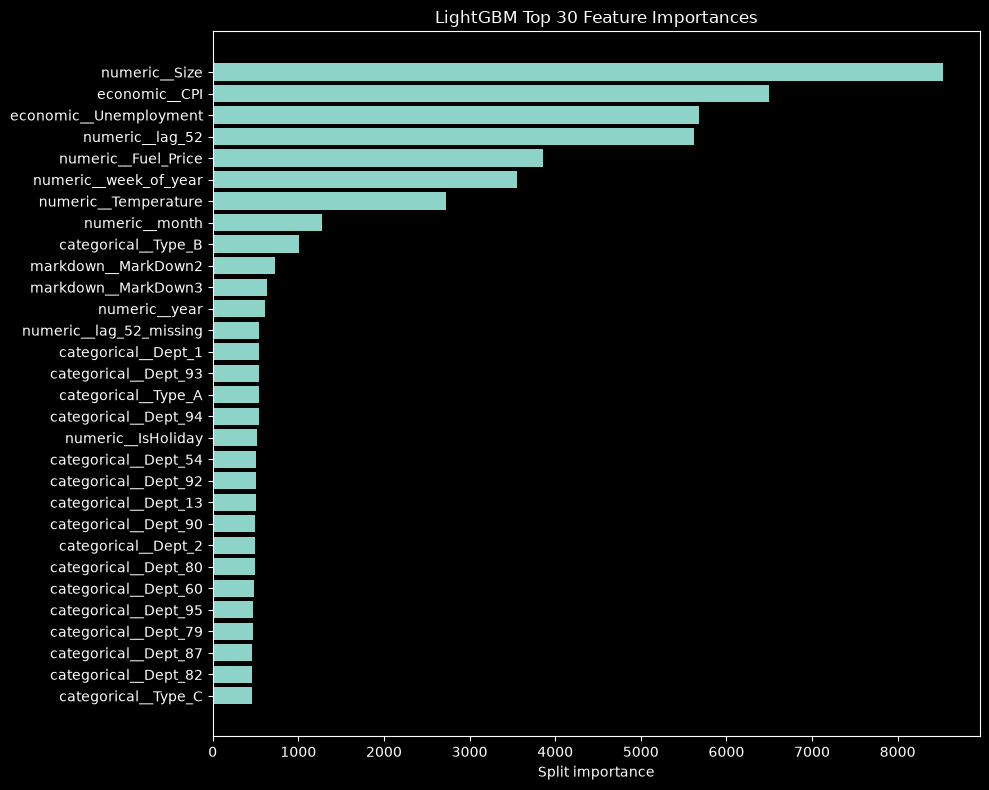

,feature,importance
0,numeric__Size,8535
1,economic__CPI,6503
2,economic__Unemployment,5679
3,numeric__lag_52,5617
4,numeric__Fuel_Price,3862
5,numeric__week_of_year,3552
6,numeric__Temperature,2724
7,numeric__month,1273
8,categorical__Type_B,1013
9,markdown__MarkDown2,733


In [20]:
feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

feature_importance = (
    pd.DataFrame(
        {
            "feature": (
                feature_names
            ),
            "importance": (
                final_model
                .feature_importances_
            ),
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

top_features = (
    feature_importance
    .head(30)
)

figure, axis = plt.subplots(
    figsize=(10, 8)
)

axis.barh(
    top_features[
        "feature"
    ][::-1],
    top_features[
        "importance"
    ][::-1],
)

axis.set_title(
    "LightGBM Top 30 Feature Importances"
)

axis.set_xlabel(
    "Split importance"
)

figure.tight_layout()
plt.show()

top_features

## Final Pipeline

In [21]:
final_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            final_preprocessor,
        ),
        (
            "model",
            final_model,
        ),
    ]
)

pipeline_predictions = (
    final_pipeline.predict(
        holdout_features.head(100)
    )
)

direct_predictions = (
    final_model.predict(
        x_holdout[:100]
    )
)

np.testing.assert_allclose(
    pipeline_predictions,
    direct_predictions,
)

print(
    "Pipeline prediction check passed."
)

Pipeline prediction check passed.


/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Final MLFlow logging

In [22]:
best_cv_result = (
    tuning_results.iloc[0]
)

final_metrics = {
    "cv_wmae_mean": float(
        best_cv_result[
            "cv_wmae_mean"
        ]
    ),
    "cv_wmae_std": float(
        best_cv_result[
            "cv_wmae_std"
        ]
    ),
    "holdout_wmae": float(
        holdout_metrics[
            "wmae"
        ]
    ),
    "holdout_mae": float(
        holdout_metrics[
            "mae"
        ]
    ),
    "holdout_rmse": float(
        holdout_metrics[
            "rmse"
        ]
    ),
}

final_run_name = make_run_name(
    architecture=ARCHITECTURE,
    stage="final",
    feature_set=best_trial[
        "feature_set"
    ],
    trial_name="best",
)

final_parameters_for_logging = (
    build_common_parameters(
        architecture=ARCHITECTURE,
        stage="final",
        feature_set=best_trial[
            "feature_set"
        ],
        preprocessing=best_trial[
            "preprocessing"
        ],
        evaluation_scope=(
            "full_dataset"
        ),
        forecast_strategy=(
            "global_tabular"
        ),
        series_count=series_count,
        extra_parameters={
            **final_parameters,
            "lags": list(
                best_trial[
                    "lags"
                ]
            ),
            "include_economic": (
                best_trial[
                    "include_economic"
                ]
            ),
            "markdown_strategy": (
                best_trial[
                    "markdown_strategy"
                ]
            ),
            "selected_trial_id": (
                best_trial_id
            ),
        },
    )
)

final_run_name

'lightgbm__final__core_calendar_lag52_v1__best__s42'

In [28]:
input_example = (
    holdout_features
    .head(10)
    .copy()
)

input_example_predictions = (
    final_pipeline.predict(
        input_example
    )
)

model_signature = infer_signature(
    input_example,
    input_example_predictions,
)

model_info = None

with mlflow_run(
    experiment_name=EXPERIMENT_NAME,
    run_name=final_run_name,
    parameters=final_parameters_for_logging,
    tags={
        "architecture": ARCHITECTURE,
        "stage": "final",
        "scope": "full_dataset",
        "selected_trial_id": (
            best_trial_id
        ),
    },
):
    mlflow.log_metrics(
        {
            **final_metrics,
            "fit_seconds": (
                final_fit_seconds
            ),
            "predict_seconds": (
                final_predict_seconds
            ),
            "final_n_estimators": (
                final_n_estimators
            ),
        }
    )

    model_info = mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        name="model",
        input_example=input_example,
        signature=model_signature,
        serialization_format=(
            mlflow.sklearn
            .SERIALIZATION_FORMAT_CLOUDPICKLE
        ),
    )

    mlflow.log_dict(
        {
            "holdout_metrics": (
                final_metrics
            )
        },
        "evaluation/final_metrics.json",
    )

    with TemporaryDirectory() as (
        temporary_directory
    ):
        temporary_path = Path(
            temporary_directory
        )

        tuning_path = (
            temporary_path
            / "tuning_results.csv"
        )

        predictions_path = (
            temporary_path
            / "holdout_predictions.csv"
        )

        importance_path = (
            temporary_path
            / "feature_importance.csv"
        )

        holiday_path = (
            temporary_path
            / "holiday_diagnostics.csv"
        )

        department_path = (
            temporary_path
            / "department_diagnostics.csv"
        )

        tuning_results.to_csv(
            tuning_path,
            index=False,
        )

        holdout_prediction_frame.to_csv(
            predictions_path,
            index=False,
        )

        feature_importance.to_csv(
            importance_path,
            index=False,
        )

        holiday_diagnostics.to_csv(
            holiday_path,
        )

        department_diagnostics.to_csv(
            department_path,
        )

        mlflow.log_artifacts(
            str(temporary_path),
            artifact_path="evaluation",
        )

    mlflow.log_figure(
        figure,
        "evaluation/feature_importance.png",
    )

print(
    "Logged final run:",
    final_run_name,
)

print(
    "Model URI:",
    model_info.model_uri,
)

print(final_metrics)

/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-miss

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

2026/07/08 21:57:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🏃 View run lightgbm__final__core_calendar_lag52_v1__best__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/4/runs/4798f650278941f99d5e0e32a68fca3b
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/4
Logged final run: lightgbm__final__core_calendar_lag52_v1__best__s42
Model URI: models:/m-d85909fdb4934fbe9a97893601b86670
{'cv_wmae_mean': 1949.1676368003598, 'cv_wmae_std': 497.77745282357165, 'holdout_wmae': 1707.1122212088237, 'holdout_mae': 1713.6277844355252, 'holdout_rmse': 3646.4236836161194}


In [29]:
loaded_pipeline = mlflow.pyfunc.load_model(
    model_info.model_uri
)

loaded_predictions = (
    loaded_pipeline.predict(
        input_example
    )
)

np.testing.assert_allclose(
    np.asarray(
        loaded_predictions
    ),
    np.asarray(
        input_example_predictions
    ),
    rtol=1e-6,
    atol=1e-6,
)

print(
    "Logged model reload check passed."
)

Logged model reload check passed.


/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Save result

In [30]:
result_row = build_result_row(
    architecture=ARCHITECTURE,
    run_name=final_run_name,
    stage="final",
    tracker="mlflow",
    feature_set=best_trial[
        "feature_set"
    ],
    preprocessing=best_trial[
        "preprocessing"
    ],
    evaluation_scope=(
        "full_dataset"
    ),
    forecast_strategy=(
        "global_tabular"
    ),
    series_count=series_count,
    metrics=final_metrics,
    fit_seconds=(
        final_fit_seconds
    ),
    predict_seconds=(
        final_predict_seconds
    ),
    notes=(
        "Configuration selected by "
        "mean CV WMAE. Final holdout "
        "evaluated once."
    ),
)

save_architecture_result(
    result_row
)

pd.DataFrame(
    [result_row]
)

,architecture,run_name,stage,tracker,feature_set,preprocessing,validation_id,data_version,evaluation_scope,forecast_strategy,series_count,random_seed,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,fit_seconds,predict_seconds,notes
0,lightgbm,lightgbm__final__core_calendar_lag52_v1__best_...,final,mlflow,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,expanding_3x13_holdout_39_v1,processed_v1,full_dataset,global_tabular,3306,42,"1,949.1676",497.7775,"1,707.1122","1,713.6278","3,646.4237",29.4280,0.6944,Configuration selected by mean CV WMAE. Final ...
